## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Implementing SVM(Support Vector Machine)</p>

## Support Vector Regression (SVR)

Support Vector Regression (SVR) is a supervised machine learning algorithm used to predict continuous values. It can model both linear and non-linear relationships using kernel functions. SVR aims to find the best-fit function while allowing a small margin of error, making it effective for complex datasets.

### Advantages:
Handles non-linear relationships.

Works well with high-dimensional data.

Reduces overfitting through regularization.

### Limitations:

Requires feature scaling.

Can be slow on large datasets.

Performance depends on parameter tuning (C, gamma, and epsilon).


## Import Required Libraries and Load the dataset

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SVR is the regression version of Support Vector Machine.
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns


## Load the dataset

In [3]:
# Load the dataset
df = pd.read_csv("../data/processed/auto_scout_final.csv")
df.shape

(15915, 140)

## Define X and y

In [11]:
X = df.drop("price", axis=1)
y = df["price"]

## Remove Rare Dummy Column

In [12]:
X = X.drop(columns=["make_model_Audi A2"])

## Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Scale Data

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Create the SVR Model

In [23]:
# Create an SVR model using the Radial Basis Function (RBF) kernel.
# kernel='rbf' : Captures non-linear relationships.
# C=100        : Controls the penalty for prediction errors (higher = closer fit).
# gamma='scale': Automatically calculates the kernel coefficient based on the data.
# epsilon=0.1  : Sets the error margin where small prediction errors are ignored.

svr = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

## Train the Model

In [16]:
svr.fit(X_train_scaled, y_train)

SVR(C=100)

## Predict

In [17]:
y_pred_svr = svr.predict(X_test_scaled)

## Evaluate

In [18]:
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 2313.76
RMSE : 4101.23
R²   : 0.6883


## Actual vs Predicted

In [21]:
svr_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_svr
})

svr_results.head(10)

,Actual Price,Predicted Price
12887,26379,20264.574704
8140,18990,17773.425043
6835,12490,13111.034587
15439,32975,27647.508885
1213,15888,16150.191317
13187,15480,15291.666625
1034,20500,17909.902804
2864,16760,18538.078881
7061,18990,17384.863746
14983,27000,20419.788021


## Plot

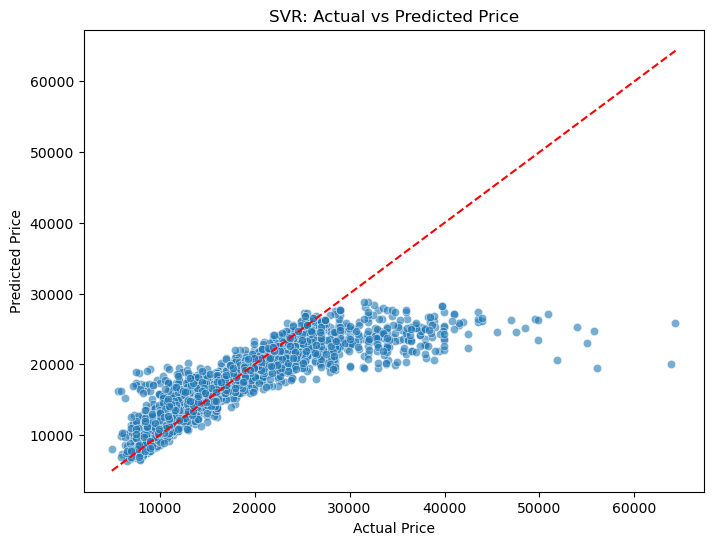

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred_svr, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR: Actual vs Predicted Price")
plt.show()

#### The scatter plot shows a tendency to underestimate expensive cars, resulting in a lower R² score and higher prediction errors. Overall, SVR performed worse than the Linear Regression model for this dataset.

## Prediction Range

In [22]:
print("Minimum Prediction:", y_pred_svr.min())
print("Maximum Prediction:", y_pred_svr.max())

Minimum Prediction: 6365.646457998228
Maximum Prediction: 28860.5094337435


### The Support Vector Regression (SVR) model was used to predict car prices based on the selected features. The model achieved an MAE of 2313.76, RMSE of 4101.23, and an R² score of 0.6883. Compared with the Linear Regression model, SVR produced larger prediction errors and explained less of the variation in car prices. Therefore, SVR was not the best-performing model for this dataset.